![](../images/logos/KIEPSKIES.jpg)

# Unsupervised Learning - Clustering 

In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns

**K-Means Clustering**

In [10]:
 #Use the iris data set 
from sklearn.datasets import load_iris 
iris = load_iris()

In [11]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [12]:
df = pd.DataFrame(iris.data, 
                  columns = iris.feature_names)
df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
from sklearn.cluster import KMeans

inertias = []

for i in range(1, 11): 
    km = KMeans(n_clusters = i)
    km.fit(iris.data)
    inertias.append(km.inertia_)

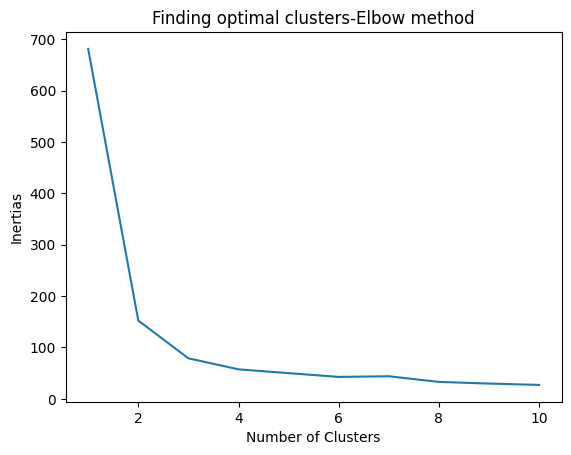

In [17]:
plt.plot(range(1, 11), inertias)
plt.title("Finding optimal clusters-Elbow method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertias")
plt.show()

In [19]:
np.unique(iris.target)

array([0, 1, 2])

In [22]:
km3 = KMeans(n_clusters=3, random_state=42)
df["Clusters"] = km3.fit_predict(iris.data)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Clusters
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


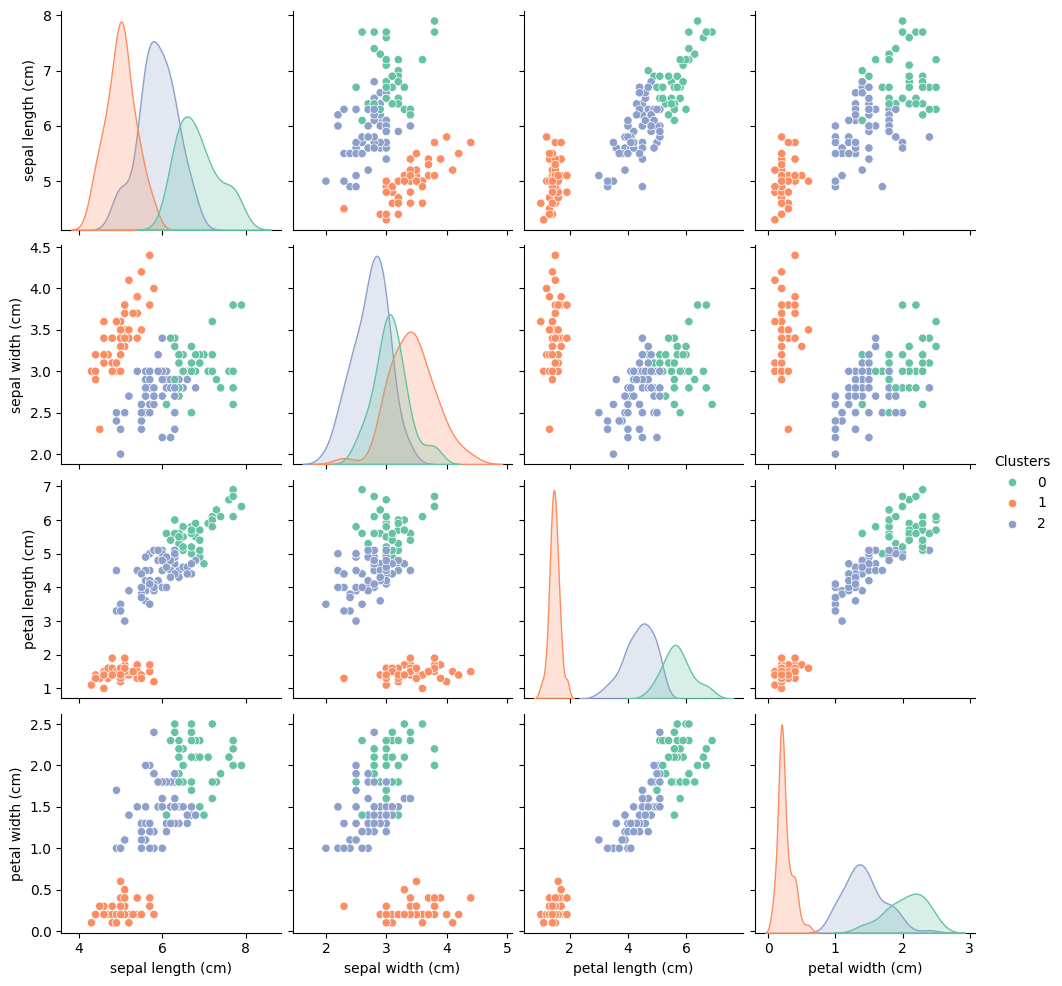

In [29]:
X = df.drop(columns=["target"])

# Visualize the clusters 
sns.pairplot(X, hue="Clusters", palette="Set2")
plt.show()

## DBSCAN 

In [35]:
from sklearn.cluster import DBSCAN

X = df[iris.feature_names]

## Apply the DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples = 5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X)

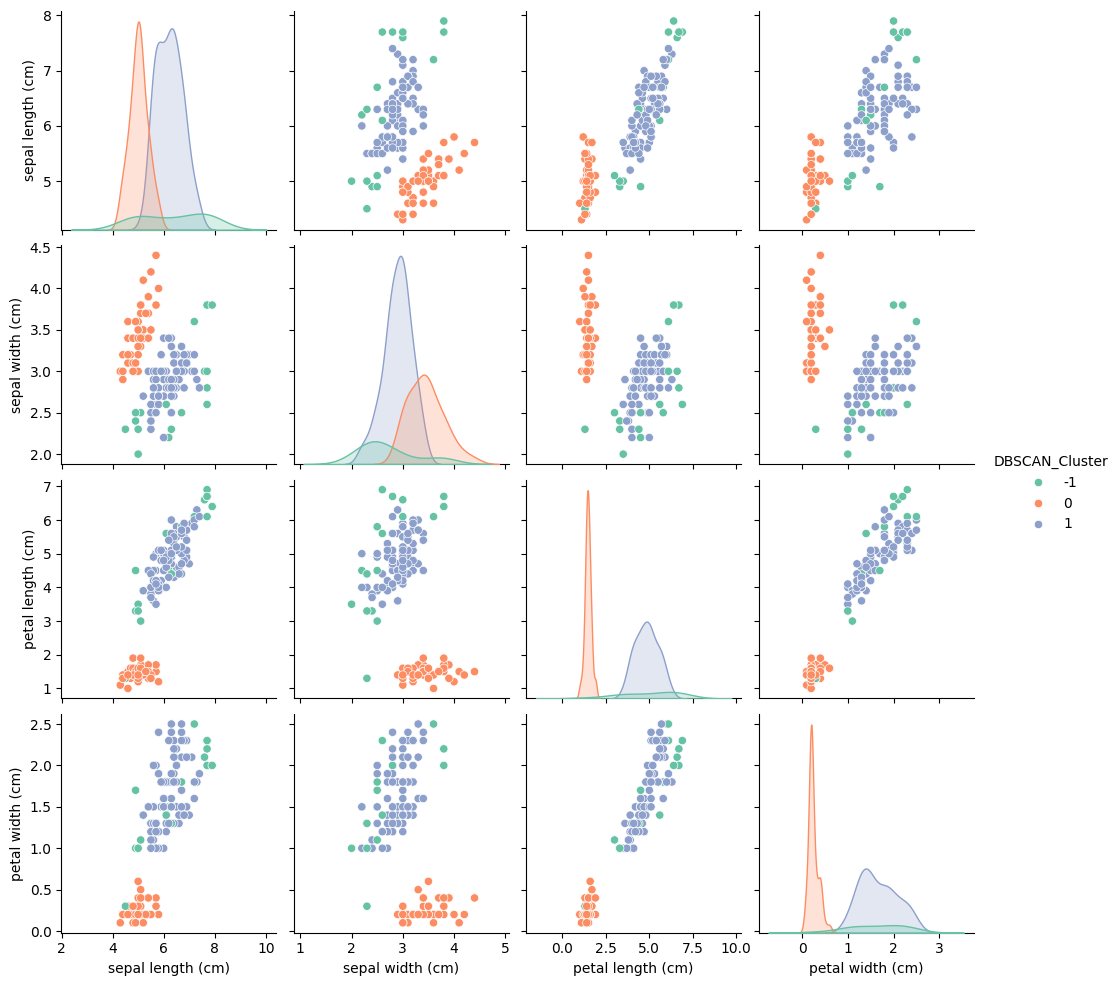

In [36]:
# Visualize the clusters 
X = df.drop(columns = ["target", "Clusters"])

sns.pairplot(X, hue="DBSCAN_Cluster", palette="Set2")
plt.show()